# Title: Personalized  Disease prediction with Medical Recommendation System For Bahir Dar University Students



#  Step 1: Import necessary Libraries

In [ ]:

import pandas as pd  
import numpy as np 
from sklearn.model_selection import train_test_split ,cross_val_score 
from sklearn.preprocessing import LabelEncoder 
from sklearn.svm import SVC  
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier  
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.naive_bayes import MultinomialNB  
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,confusion_matrix
# Library for saving and loading the trained model
import pickle  # Used to serialize and deserialize the trained SVC model.
import matplotlib.pyplot as plt                     
import seaborn as sns                                 
from sklearn.pipeline import Pipeline                 


In [ ]:
import re

def normalize_disease_name(name):
    name = str(name).strip() # Strip leading/trailing whitespace
    name = re.sub(r'[\(\[].*?[\)\]]', '', name) # Remove content in parentheses or brackets, and the parentheses/brackets themselves
    name = re.sub(r'[^a-zA-Z0-9\s]', '', name) # Remove other special characters
    name = re.sub(r'\s+', ' ', name) # Replace multiple spaces with a single space
    return name.strip() # Final strip after all replacements

## Step 2:Data Loading

In [ ]:
dataset = pd.read_csv(r'C:\Users\lenevo\Desktop\Teklemariam\Training_Modified.csv')
dataset['Prognosis'] = dataset['Prognosis'].apply(normalize_disease_name)

In [ ]:
dataset

,Age,abdominal cramp,abdominal discomfort,abdominal distension,abdominal pain,abdominal sounds,aphonia,back pain,bloody diarrhea,burning sensation during urination,...,nausea,productive cough,rectal pain,skin itching,sore throat,sweating,tenesmus,vomiting,weakness,Prognosis
0,20,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Acute Febrile Illness
1,20,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Acute Febrile Illness
2,20,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,Acute Febrile Illness
3,20,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,Acute Febrile Illness
4,20,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Acute Febrile Illness
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133,22,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Upper Respiratory Tract Infection
134,22,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Upper Respiratory Tract Infection
135,20,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Upper Respiratory Tract Infection
136,20,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Upper Respiratory Tract Infection


In [ ]:
dataset.head() # To show first 5 rows

,Age,abdominal cramp,abdominal discomfort,abdominal distension,abdominal pain,abdominal sounds,aphonia,back pain,bloody diarrhea,burning sensation during urination,...,nausea,productive cough,rectal pain,skin itching,sore throat,sweating,tenesmus,vomiting,weakness,Prognosis
0,20,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Acute Febrile Illness
1,20,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Acute Febrile Illness
2,20,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,Acute Febrile Illness
3,20,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,Acute Febrile Illness
4,20,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Acute Febrile Illness


In [ ]:
dataset.shape

(138, 39)

In [8]:
dataset.info

<bound method DataFrame.info of      Age  abdominal cramp  abdominal discomfort  abdominal distension  \
0     20                0                     0                     0   
1     20                0                     0                     0   
2     20                0                     0                     0   
3     20                0                     0                     0   
4     20                0                     0                     0   
..   ...              ...                   ...                   ...   
133   22                0                     0                     0   
134   22                0                     0                     0   
135   20                0                     0                     0   
136   20                0                     0                     0   
137   20                0                     0                     0   

     abdominal pain  abdominal sounds  aphonia  back pain  bloody diarrhea  \
0            

In [9]:
dataset.columns.tolist()

['Age',
 'abdominal cramp',
 'abdominal discomfort',
 'abdominal distension',
 'abdominal pain',
 'abdominal sounds',
 'aphonia',
 'back pain',
 'bloody diarrhea',
 'burning sensation during urination',
 'chest pain',
 'chills',
 'cough',
 'diarrhea',
 'difficulty swallowing',
 'dry cough',
 'epigastric burning',
 'epigastric pain',
 'fatigability',
 'fever',
 'flank pain',
 'gastrointestinal distress',
 'headache',
 'indigestion',
 'joint pain',
 'loss of appetite',
 'lower abdominal pain',
 'malaise',
 'nasal discharge',
 'nausea',
 'productive cough',
 'rectal pain',
 'skin itching',
 'sore throat',
 'sweating',
 'tenesmus',
 'vomiting',
 'weakness',
 'Prognosis']

In [12]:
# Flatten all dataset values into 1D
vals = dataset.drop(columns=['Prognosis']).values.flatten()
vals

array([20,  0,  0, ...,  0,  0,  0])

all values are the same (symptom always present)


##    load other Datasets used to any logic and recommendations task

In [ ]:
Dosage= pd.read_csv(r'C:\Users\lenevo\Desktop\Teklemariam\Dosage.csv')
precautions = pd.read_csv(r'C:\Users\lenevo\Desktop\Teklemariam\Precaution.csv')
description = pd.read_csv(r'C:\Users\lenevo\Desktop\Teklemariam\Description.csv')
medications = pd.read_csv(r'C:\Users\lenevo\Desktop\Teklemariam\Medication.csv')
diets = pd.read_csv(r'C:\Users\lenevo\Desktop\Teklemariam\Diets.csv')

# Strip whitespace from 'Disease' columns for consistent matching
description['Disease'] = description['Disease'].apply(normalize_disease_name)
precautions['Disease'] = precautions['Disease'].apply(normalize_disease_name)
medications['Disease'] = medications['Disease'].apply(normalize_disease_name)
diets['Disease'] = diets['Disease'].apply(normalize_disease_name)

In [15]:
Dosage

,Age,Treatment,Dosage
0,20,Albendazole,400 mg single dose or daily for 3 days
1,21,Albendazole,425 mg single dose or daily for 3 days
2,22,Albendazole,450 mg single dose or daily for 3 days
3,23,Albendazole,475 mg single dose or daily for 3 days
4,24,Albendazole,500 mg single dose or daily for 3 days
...,...,...,...
146,23,Tinidazole,2.3 g single oral dose
147,24,Tinidazole,2.4 g single oral dose
148,25,Tinidazole,2.5 g single oral dose
149,26,Tinidazole,2.6 g single oral dose


In [ ]:
precautions

,Disease,Precaution
0,Acute Febrile Illness,"Use mosquito nets, eliminate standing water, a..."
1,Acute Gastroenteritis,"Maintain strict hand hygiene, consume treated ..."
2,Intestinal Parasites,"Avoid contact with contaminated soil, ensure p..."
3,Upper Respiratory Tract Infection,Avoid close contact with symptomatic individua...


In [ ]:

precautions.fillna("None", inplace=True)  # Handling missing value
precautions

,Disease,Precaution
0,Acute Febrile Illness,"Use mosquito nets, eliminate standing water, a..."
1,Acute Gastroenteritis,"Maintain strict hand hygiene, consume treated ..."
2,Intestinal Parasites,"Avoid contact with contaminated soil, ensure p..."
3,Upper Respiratory Tract Infection,Avoid close contact with symptomatic individua...


In [ ]:
precautions

,Disease,Precaution
0,Acute Febrile Illness,"Use mosquito nets, eliminate standing water, a..."
1,Acute Gastroenteritis,"Maintain strict hand hygiene, consume treated ..."
2,Intestinal Parasites,"Avoid contact with contaminated soil, ensure p..."
3,Upper Respiratory Tract Infection,Avoid close contact with symptomatic individua...


In [19]:
description

,Disease,Description
0,Acute Febrile Illness,AFI is a clinical syndrome characterized by a ...
1,Acute Gastroenteritis,AGE is an inflammatory condition of the gastro...
2,Intestinal Parasites,I/P is a disease condition caused by helminths...
3,Upper Respiratory Tract Infection,URTI is an infectious disease affecting the up...


In [ ]:
description.isnull().sum()

Disease        0
Description    0
dtype: int64

In [ ]:
medications

,Disease,medication
0,Acute Febrile Illness,"Chloroquine, Primaquine, Paracetamol, Coartem,..."
1,Acute Gastroenteritis,"Ciprofloxacin, ORS, Paracetamol, Metronidazole..."
2,Intestinal Parasites,"Albendazole, Ciprofloxacin, Metronidazole, Cou..."
3,Upper Respiratory Tract Infection,"Azithromycin, Paracetamol, Coartem, Doxycyclin..."


In [22]:
medications.isnull().sum()

Disease       0
medication    0
dtype: int64

In [ ]:
diets

,Disease,Diets
0,Acute Febrile Illness,"High-calorie, high-protein diet with soft food..."
1,Acute Gastroenteritis,Oral rehydration (ORS) and a bland diet (Banan...
2,Intestinal Parasites,"High-fiber foods to support bowel health, prob..."
3,Upper Respiratory Tract Infection,"Warm fluids (soups/teas), honey and ginger for..."


##   Step 3:Data Preprocessing  For main dataset

In [ ]:
dataset.isnull().sum()

Age                                   0
abdominal cramp                       0
abdominal discomfort                  0
abdominal distension                  0
abdominal pain                        0
abdominal sounds                      0
aphonia                               0
back pain                             0
bloody diarrhea                       0
burning sensation during urination    0
chest pain                            0
chills                                0
cough                                 0
diarrhea                              0
difficulty swallowing                 0
dry cough                             0
epigastric burning                    0
epigastric pain                       0
fatigability                          0
fever                                 0
flank pain                            0
gastrointestinal distress             0
headache                              0
indigestion                           0
joint pain                            0


In [ ]:
import pandas as pd
duplicated_sum = dataset.duplicated().sum()
Data_clear = dataset
print(f"The number of duplicated rows is: {duplicated_sum}")
print(f"The number of unique rows after dropping duplicates is: {Data_clear.shape[0]}")


The number of duplicated rows is: 0
The number of unique rows after dropping duplicates is: 138


In [ ]:

X = Data_clear.drop('Prognosis', axis=1)
y = Data_clear['Prognosis'].str.strip()

In [ ]:
X


,Age,abdominal cramp,abdominal discomfort,abdominal distension,abdominal pain,abdominal sounds,aphonia,back pain,bloody diarrhea,burning sensation during urination,...,nasal discharge,nausea,productive cough,rectal pain,skin itching,sore throat,sweating,tenesmus,vomiting,weakness
0,20,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,20,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,20,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,0
3,20,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,20,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133,22,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
134,22,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
135,20,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
136,20,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
y

0                  Acute Febrile Illness
1                  Acute Febrile Illness
2                  Acute Febrile Illness
3                  Acute Febrile Illness
4                  Acute Febrile Illness
                     ...                
133    Upper Respiratory Tract Infection
134    Upper Respiratory Tract Infection
135    Upper Respiratory Tract Infection
136    Upper Respiratory Tract Infection
137    Upper Respiratory Tract Infection
Name: Prognosis, Length: 138, dtype: object

In [ ]:

le = LabelEncoder()  
le.fit(y)           
Y = le.transform(y) 
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)  # 20% fortesting and 80% taining

In [ ]:
Y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3])

In [ ]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((110, 38), (28, 38), (110,), (28,))

In [ ]:
y_train

array([0, 3, 1, 0, 3, 2, 2, 3, 3, 0, 3, 3, 0, 0, 1, 3, 2, 0, 0, 3, 0, 0,
       1, 3, 3, 0, 0, 2, 3, 0, 0, 3, 0, 2, 1, 0, 2, 2, 1, 0, 2, 2, 1, 0,
       0, 2, 0, 0, 2, 2, 3, 3, 0, 0, 3, 0, 0, 0, 2, 3, 0, 2, 3, 3, 1, 1,
       2, 0, 2, 1, 3, 2, 3, 2, 0, 1, 2, 0, 2, 3, 3, 1, 2, 0, 3, 1, 1, 3,
       0, 0, 3, 3, 0, 1, 0, 0, 0, 3, 3, 3, 2, 2, 3, 3, 0, 2, 3, 0, 2, 3])

## Step 4:Data Visualization

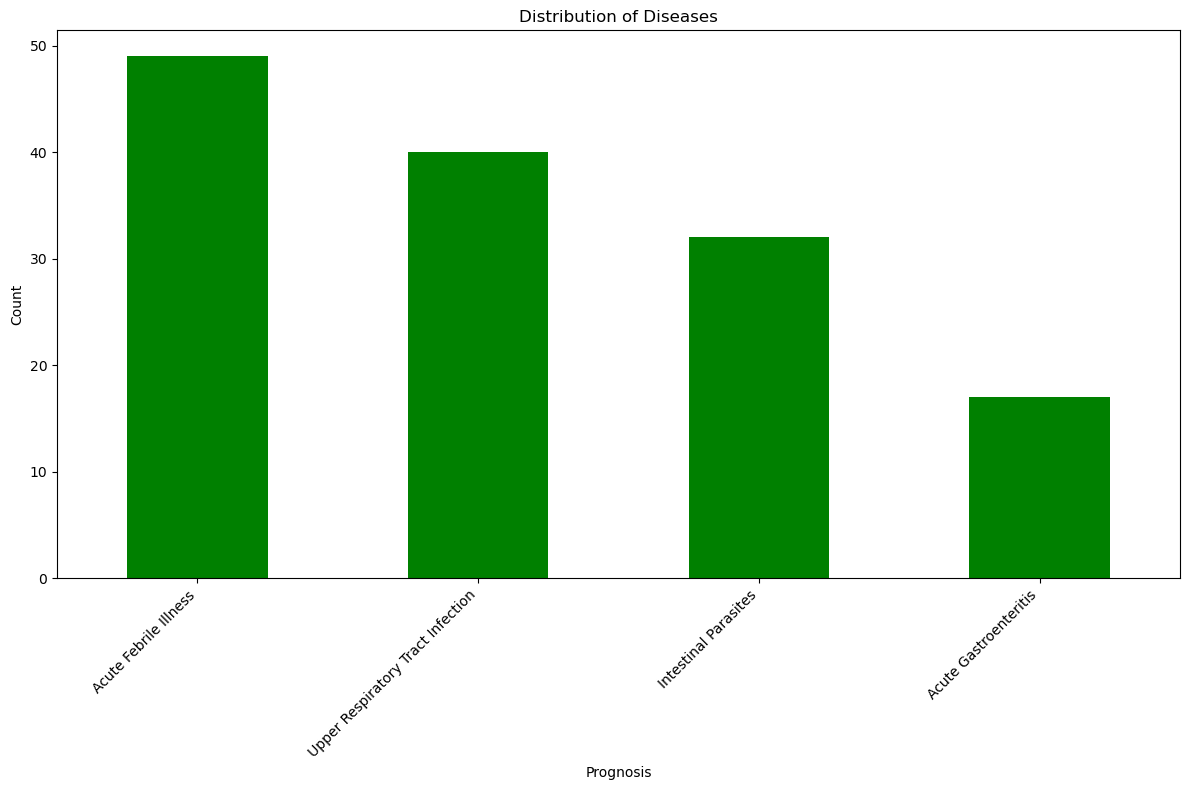

In [ ]:
# Visualize the distribution of diseases (prognosis)
plt.figure(figsize=(12, 8))
Data_clear['Prognosis'].value_counts().plot(kind='bar', color='Green')
plt.title('Distribution of Diseases')
plt.xlabel('Prognosis')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The bar chart displays the distribution of diseases, showing their frequency or count. Diseases like Hepatitis D, Chickenpox, and Dengue,Migraine are the most common, each with a count of 10. Conversely, diseases such as Acne, Urinary tract infection, and Fungal infection are the least frequent, with a count of 5 each.

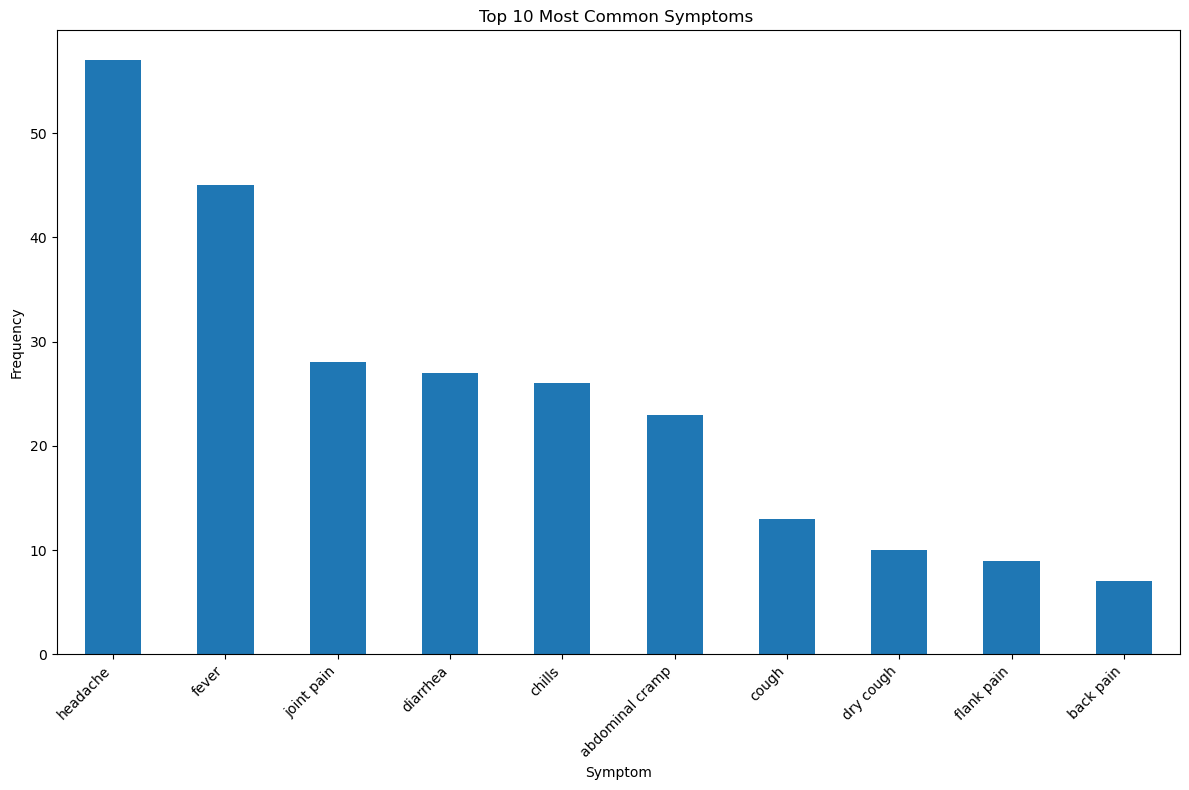

In [ ]:
import matplotlib.pyplot as plt

# Drop both 'Prognosis' and 'Age'
symptoms = Data_clear.drop(['Prognosis', 'Age'], axis=1) \
                     .sum() \
                     .sort_values(ascending=False)[:10]
# Plot
plt.figure(figsize=(12, 8))
symptoms.plot(kind='bar')

plt.title('Top 10 Most Common Symptoms ')
plt.xlabel('Symptom')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

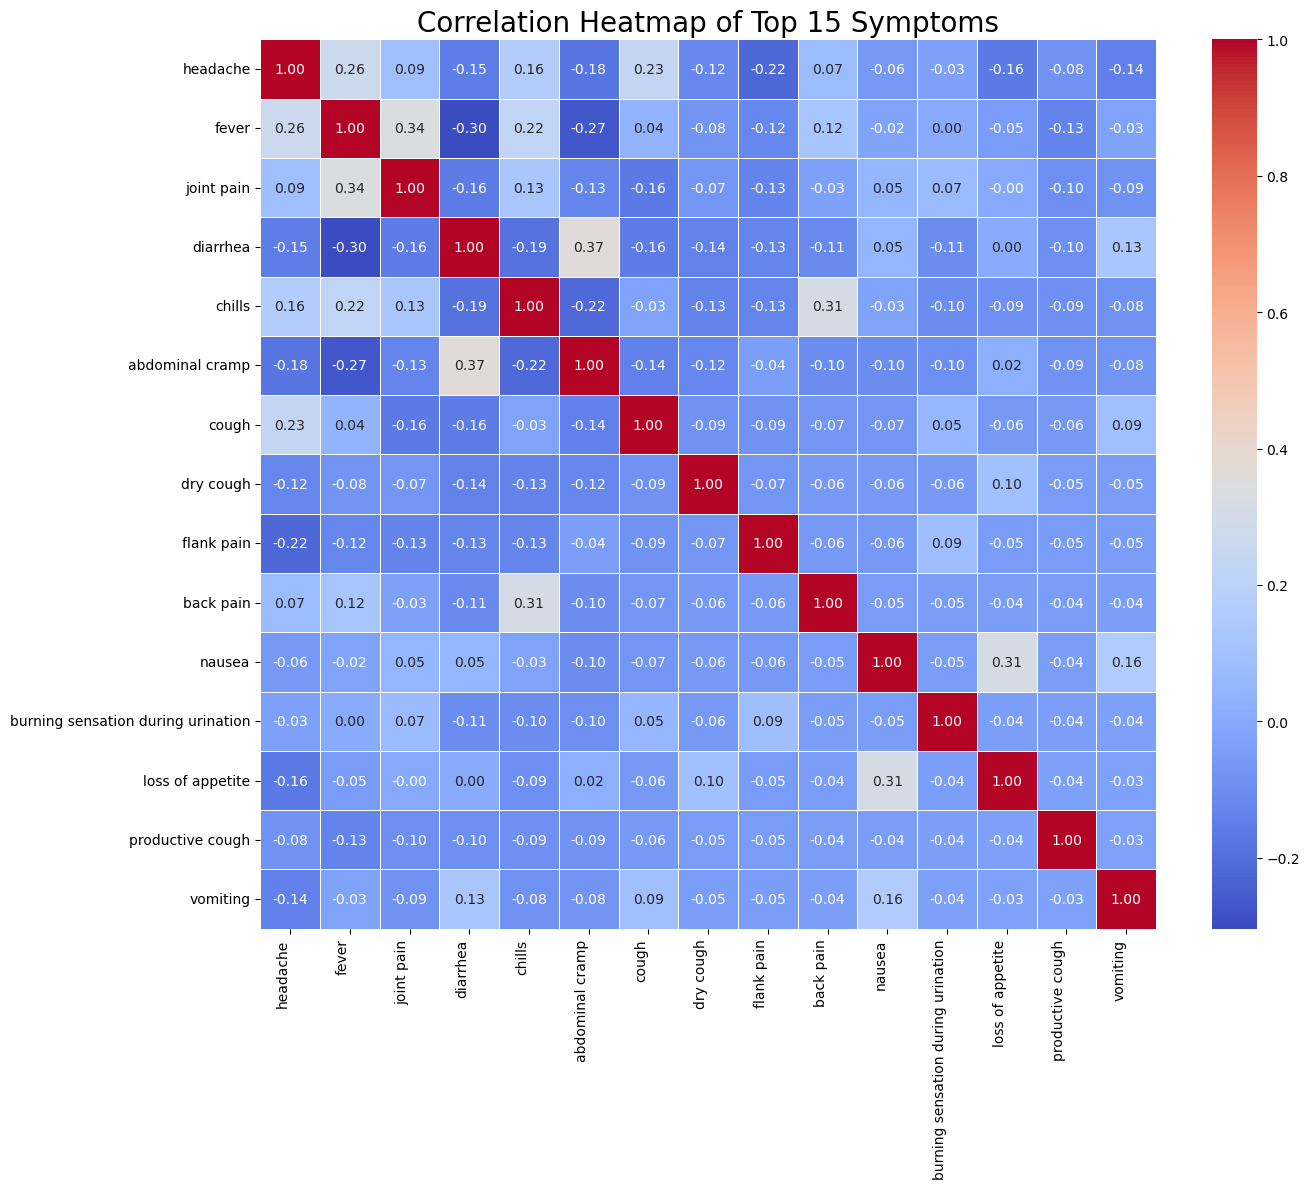

In [ ]:
# Select a subset of the top 15 most frequent symptoms
symptom_df = Data_clear.drop(columns=['Prognosis','Age' ], errors='ignore')
symptom_frequency = symptom_df.sum().sort_values(ascending=False).head(20)
top_15_symptoms = symptom_frequency.head(15).index
correlation_df = Data_clear[top_15_symptoms]
correlation_matrix = correlation_df.corr()
plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, annot_kws={"size": 10})

# Add titles and labels
plt.title('Correlation Heatmap of Top 15 Symptoms', fontsize=20)
plt.xticks(rotation=90, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig('symptom_correlation_heatmap.png')
plt.show()

# Step 5:Model comparition

In [ ]:
# Create a dictionary to store models
models = {
    'SVC': SVC(kernel='linear'),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'KNeighbors': KNeighborsClassifier(n_neighbors=5),
    'MultinomialNB': MultinomialNB()
}

# Loop through the models, train, test, and print results
for model_name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)

    # Test the model
    predictions = model.predict(X_test)

    # Calculate accuracy
    accuracy = accuracy_score(y_test, predictions)
    print(f"{model_name} Accuracy: {accuracy}")

    # Calculate confusion matrix
    cm = confusion_matrix(y_test, predictions)
    print(f"{model_name} Confusion Matrix:")
    print(np.array2string(cm, separator=', '))

    print("\n" + "="*40 + "\n")

SVC Accuracy: 0.6428571428571429
SVC Confusion Matrix:
[[7, 0, 1, 3],
 [0, 2, 0, 1],
 [0, 2, 5, 0],
 [2, 0, 1, 4]]


RandomForest Accuracy: 0.6428571428571429
RandomForest Confusion Matrix:
[[8, 0, 0, 3],
 [0, 2, 0, 1],
 [0, 3, 3, 1],
 [2, 0, 0, 5]]


GradientBoosting Accuracy: 0.6428571428571429
GradientBoosting Confusion Matrix:
[[8, 0, 0, 3],
 [0, 2, 0, 1],
 [0, 3, 4, 0],
 [2, 0, 1, 4]]


KNeighbors Accuracy: 0.5714285714285714
KNeighbors Confusion Matrix:
[[8, 0, 0, 3],
 [0, 1, 1, 1],
 [0, 4, 3, 0],
 [2, 0, 1, 4]]


MultinomialNB Accuracy: 0.7142857142857143
MultinomialNB Confusion Matrix:
[[8, 0, 0, 3],
 [0, 0, 2, 1],
 [0, 0, 7, 0],
 [1, 0, 1, 5]]




In [ ]:
import time

# Define models with a "simplicity score" (lower = simpler)
models = {
    'SVC': {'model': SVC(kernel='linear'), 'simplicity': 1},
    'MultinomialNB': {'model': MultinomialNB(), 'simplicity': 2},
    'KNeighbors': {'model': KNeighborsClassifier(n_neighbors=5), 'simplicity': 3},
    'RandomForest': {'model': RandomForestClassifier(n_estimators=100, random_state=42), 'simplicity': 4},
    'GradientBoosting': {'model': GradientBoostingClassifier(n_estimators=100, random_state=42), 'simplicity': 5}
}

best_model_name = None
best_model = None
best_accuracy = -1
best_cv_score = -1
best_simplicity = float('inf')
best_train_time = float('inf')

# Compare models
for name, info in models.items():
    model = info['model']
    simplicity = info['simplicity']

    # Measure training time
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time

    # Test accuracy
    y_pred = model.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred)

    # Cross-validation score (5-fold)
    cv_score = cross_val_score(model, X_train, y_train, cv=5).mean()

    print(f"{name}: Test Acc={test_acc}, CV Acc={cv_score:.4f}, Train Time={train_time:.4f}s, Simplicity={simplicity}")

    # Decision logic: prioritize accuracy, then CV, then simplicity, then training speed
    if test_acc > best_accuracy \
        or (test_acc == best_accuracy and cv_score > best_cv_score) \
        or (test_acc == best_accuracy and cv_score == best_cv_score and simplicity < best_simplicity) \
        or (test_acc == best_accuracy and cv_score == best_cv_score and simplicity == best_simplicity and train_time < best_train_time):

        best_model_name = name
        best_model = model
        best_accuracy = test_acc
        best_cv_score = cv_score
        best_simplicity = simplicity
        best_train_time = train_time

# Show best model
print("\n" + "="*50)
print(f"Best Model: {best_model_name}")
print(f"Test Accuracy: {best_accuracy}")
print(f"Cross-Validation Score: {best_cv_score:.4f}")
print(f"Training Time: {best_train_time:.4f}s")
print("Confusion Matrix:\n", confusion_matrix(y_test, best_model.predict(X_test)))

SVC: Test Acc=0.6428571428571429, CV Acc=0.7364, Train Time=0.0128s, Simplicity=1
MultinomialNB: Test Acc=0.7142857142857143, CV Acc=0.7727, Train Time=0.0034s, Simplicity=2
KNeighbors: Test Acc=0.5714285714285714, CV Acc=0.7273, Train Time=0.0023s, Simplicity=3
RandomForest: Test Acc=0.6428571428571429, CV Acc=0.7273, Train Time=0.3262s, Simplicity=4
GradientBoosting: Test Acc=0.6428571428571429, CV Acc=0.7182, Train Time=0.8940s, Simplicity=5

Best Model: MultinomialNB
Test Accuracy: 0.7142857142857143
Cross-Validation Score: 0.7727
Training Time: 0.0034s
Confusion Matrix:
 [[8 0 0 3]
 [0 0 2 1]
 [0 0 7 0]
 [1 0 1 5]]


In [ ]:
from sklearn.metrics import classification_report

#y_pred = model_for_prediction.predict(X_test)

report = classification_report(
    y_test,
    y_pred,
    output_dict=True,
    zero_division=0
)

# Get class names from encoder
class_names = le.inverse_transform([0,1,2,3])

print("=== Recall and F1-score for each Disease ===\n")

for i, label in enumerate(class_names):
    print(f"Disease: {label}")
    print(f"  Recall   : {report[str(i)]['recall']:.3f}")
    print(f"  F1-score : {report[str(i)]['f1-score']:.3f}")
    print("-" * 40)

=== Recall and F1-score for each Disease ===

Disease: Acute Febrile Illness
  Recall   : 0.727
  F1-score : 0.762
----------------------------------------
Disease: Acute Gastroenteritis
  Recall   : 0.667
  F1-score : 0.500
----------------------------------------
Disease: Intestinal Parasites
  Recall   : 0.571
  F1-score : 0.667
----------------------------------------
Disease: Upper Respiratory Tract Infection
  Recall   : 0.571
  F1-score : 0.533
----------------------------------------


In [ ]:
from imblearn.over_sampling import RandomOverSampler
from collections import Counter

print(f"Original training set shape: {X_train.shape}, {y_train.shape}")
print(f"Original class distribution: {Counter(y_train)}")

# Initialize RandomOverSampler
ros = RandomOverSampler(random_state=42)

# Resample the training data
X_resampled, y_resampled = ros.fit_resample(X_train, y_train)

print(f"Resampled training set shape: {X_resampled.shape}, {y_resampled.shape}")
print(f"Resampled class distribution: {Counter(y_resampled)}")

# Update X_train and y_train to use the resampled data
X_train = X_resampled
y_train = y_resampled

print("Training data has been resampled and updated.")

Original training set shape: (110, 38), (110,)
Original class distribution: Counter({np.int64(0): 38, np.int64(3): 33, np.int64(2): 25, np.int64(1): 14})
Resampled training set shape: (152, 38), (152,)
Resampled class distribution: Counter({np.int64(0): 38, np.int64(3): 38, np.int64(1): 38, np.int64(2): 38})
Training data has been resampled and updated.


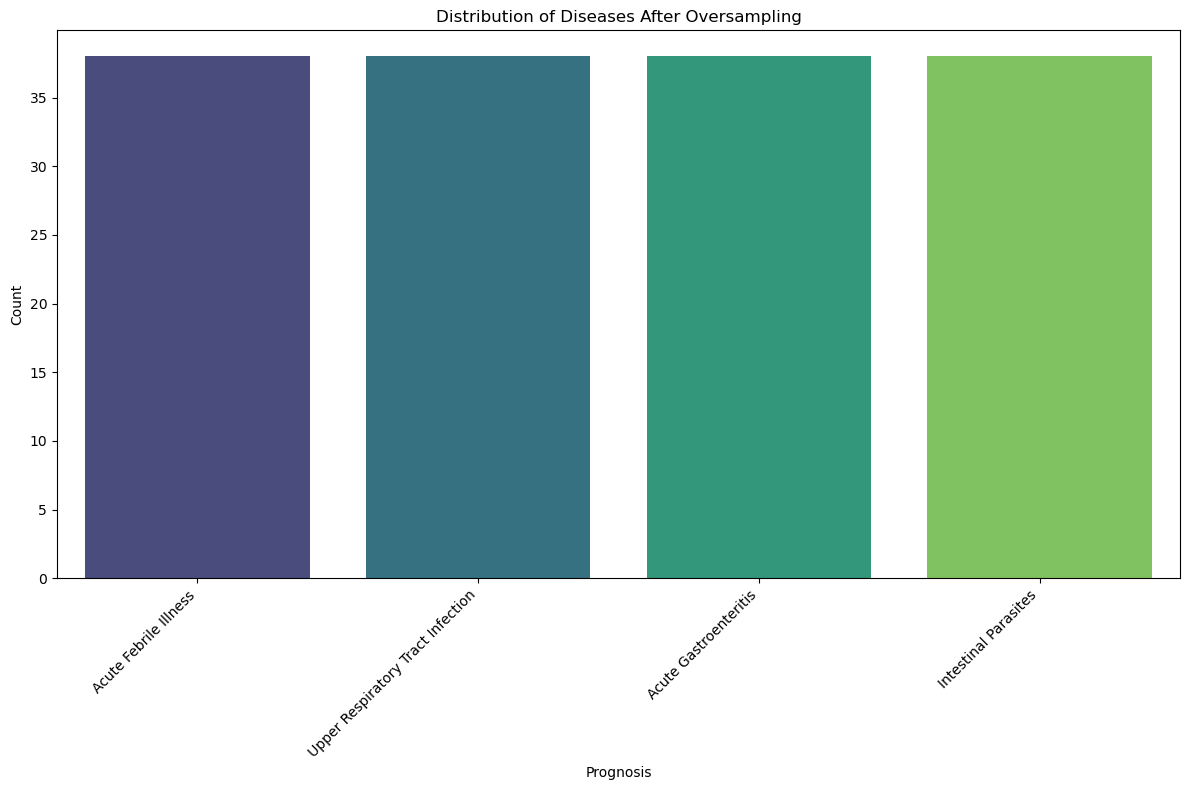

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Inverse transform the resampled numerical labels back to disease names
resampled_diseases = le.inverse_transform(y_resampled)

# Create a DataFrame or Series from the resampled diseases to get counts
resampled_disease_counts = pd.Series(resampled_diseases).value_counts()

# Visualize the distribution of diseases after balancing
plt.figure(figsize=(12, 8))
sns.barplot(x=resampled_disease_counts.index, y=resampled_disease_counts.values, palette='viridis', hue=resampled_disease_counts.index, legend=False)
plt.title('Distribution of Diseases After Oversampling')
plt.xlabel('Prognosis')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Step:7 Model fitted by Best Model (MultinomialNB)

In [ ]:
# Using the best model identified from the comparison (MultinomialNB)
model_for_prediction = best_model # This 'best_model' is from the comparison in the previous cell

# Train the model (it's already fitted in the comparison, but refitting for clarity)
model_for_prediction.fit(X_train, y_train)
ypred = model_for_prediction.predict(X_test)
accuracy_score(y_test, ypred)

0.7142857142857143

In [ ]:
model_for_prediction

MultinomialNB()

In [ ]:
save_path = r"C:\Users\lenevo\Desktop\Teklemariam\disease_model.pkl"

# Define the prediction metadata before saving
symptoms_dict = {symptom: index for index, symptom in enumerate(X.columns)}
diseases_list = le.classes_.tolist()

with open(save_path, "wb") as f:
    pickle.dump({
        "model": model_for_prediction,
        "label_encoder": le,
        "symptoms_dict": symptoms_dict,
        "diseases_list": diseases_list
    }, f)
print("Saved best model package to:", save_path)

Saved best model package to: C:\Users\lenevo\Desktop\Teklemariam\disease_model.pkl


 ##  Step 8:Model performance testing

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Predict on test set
y_pred = model_for_prediction.predict(X_test) # Changed from svc.predict

# Accuracy
acc = accuracy_score(y_test, y_pred)

# Precision, Recall, F1-score (macro average)
prec = precision_score(y_test, y_pred, average='macro', zero_division=0) # Added zero_division=0
rec = recall_score(y_test, y_pred, average='macro', zero_division=0)    # Added zero_division=0
f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)       # Added zero_division=0

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Classification Report
report = classification_report(y_test, y_pred, zero_division=0) # Added zero_division=0

print(f"Accuracy: {acc}")
print(f"Precision: {prec}")
print(f"Recall: {rec}")
print(f"F1 Score: {f1}")
print("Confusion Matrix:")
print(cm)
print("\nClassification Report:\n", report)

Accuracy: 0.7142857142857143
Precision: 0.7034722222222223
Recall: 0.7532467532467533
F1 Score: 0.7
Confusion Matrix:
[[8 0 0 3]
 [0 3 0 0]
 [0 3 4 0]
 [1 0 1 5]]

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.73      0.80        11
           1       0.50      1.00      0.67         3
           2       0.80      0.57      0.67         7
           3       0.62      0.71      0.67         7

    accuracy                           0.71        28
   macro avg       0.70      0.75      0.70        28
weighted avg       0.76      0.71      0.72        28



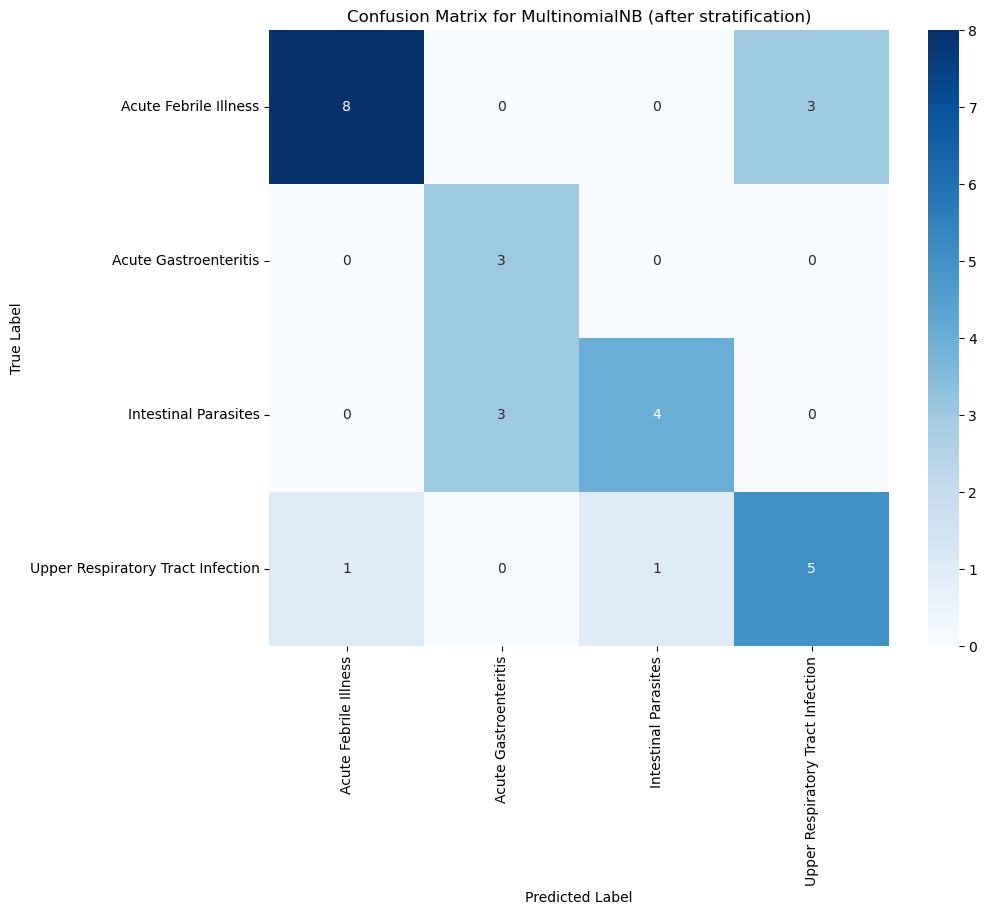

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix for MultinomialNB (after stratification)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
# test 1:
print("predicted disease :", model_for_prediction.predict(X_test.iloc[0].values.reshape(1,-1)))
print("Actual Disease :", y_test[0])

predicted disease : [2]
Actual Disease : 2


C:\Users\lenevo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MultinomialNB was fitted with feature names
  warnings.warn(


 ## Step:9 Train vs Test Accuracy

Training Accuracy: 90.79%
Testing Accuracy: 71.43%


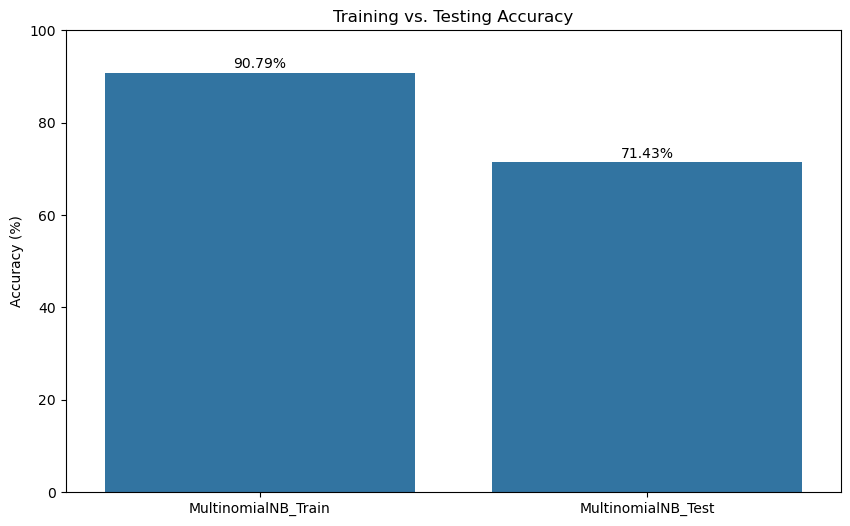

In [ ]:
# To store accuracy scores
accuracy_scores = {}

# Evaluate and plot accuracy
def evaluate_and_plot_accuracy(model_name_prefix, y_true, y_pred, model_suffix):
    accuracy = accuracy_score(y_true, y_pred) * 100 # Convert to percentage
    accuracy_scores[f"{model_name_prefix}_{model_suffix}"] = accuracy
    return accuracy

# Assuming you have trained a classifier (e.g., model_for_prediction) and have predictions
y_pred_model = model_for_prediction.predict(X_test)
y_train_pred_model = model_for_prediction.predict(X_train)

# Calculate and print accuracies
train_accuracy = evaluate_and_plot_accuracy(best_model_name, y_train, y_train_pred_model, "Train")
test_accuracy = evaluate_and_plot_accuracy(best_model_name, y_test, y_pred_model, "Test")

print(f"Training Accuracy: {train_accuracy:.2f}%")
print(f"Testing Accuracy: {test_accuracy:.2f}%")

# Create a bar plot to visualize the accuracies
models = list(accuracy_scores.keys())
scores = list(accuracy_scores.values())

plt.figure(figsize=(10, 6))
sns.barplot(x=models, y=scores)
plt.title('Training vs. Testing Accuracy')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100) # Set the y-axis limit to 100 for better visualization of percentages

# Add the percentage values on top of the bars
for index, value in enumerate(scores):
    plt.text(index, value + 1, f'{value:.2f}%', ha='center')

plt.show()

Training Accuracy: 0.9078947368421053
Test Accuracy: 0.7142857142857143


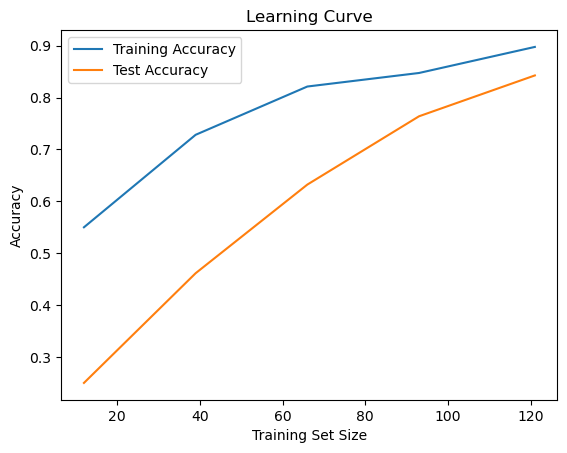

In [ ]:
from sklearn.model_selection import learning_curve
# Example with your selected model (e.g., model_for_prediction)
model = model_for_prediction # Use the best_model identified from the comparison

# Train the model (it's already fitted, but explicit fit for learning_curve is standard)
model.fit(X_train, y_train)

# Accuracy on training and test sets
train_acc = accuracy_score(y_train, model.predict(X_train))
test_acc = accuracy_score(y_test, model.predict(X_test))

print(f"Training Accuracy: {train_acc}")
print(f"Test Accuracy: {test_acc}")


# Optional: plot learning curve
train_sizes, train_scores, test_scores = learning_curve(model, X_train, y_train, cv=5, train_sizes=np.linspace(0.1,1.0,5))
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.plot(train_sizes, train_mean, label='Training Accuracy')
plt.plot(train_sizes, test_mean, label='Test Accuracy')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.title('Learning Curve')
plt.legend()
plt.show()

 ## Step 10: Detect model overfitt or underfit

In [ ]:
train_acc = model_for_prediction.score(X_train, y_train)
test_acc = model_for_prediction.score(X_test, y_test)

print(f"Training Accuracy: {train_acc:.3f}")
print(f"Testing Accuracy : {test_acc:.3f}\n")

if train_acc - test_acc > 0.05:
    print(" Possible Overfitting")
elif train_acc < 0.7 and test_acc < 0.7:
    print("Possible Underfitting")
elif train_acc == 1.0 and test_acc == 1.0:
    print("Possible Data Leakage (too perfect!)")
else:
    print(" Model looks good (no obvious overfitting/underfitting)")

Training Accuracy: 0.908
Testing Accuracy : 0.714

 Possible Overfitting


##  Step 11:Model Regularization


In [ ]:

model = model_for_prediction # Use the already trained best model
# Evaluate accuracy
train_acc_reg = model.score(X_train, y_train)
test_acc_reg = model.score(X_test, y_test)
print(f"Training Accuracy (Best Model): {train_acc_reg:.3f}")
print(f"Testing Accuracy (Best Model): {test_acc_reg:.3f}")

# Cross-validation for generalization
cv_scores_reg = cross_val_score(model, X, Y, cv=5)
print("Cross-validation scores (Best Model):", np.round(cv_scores_reg, 3))
print("Mean CV Accuracy (Best Model):", np.round(cv_scores_reg.mean(), 3))

Training Accuracy (Best Model): 0.908
Testing Accuracy (Best Model): 0.714
Cross-validation scores (Best Model): [0.607 0.857 0.75  0.852 0.63 ]
Mean CV Accuracy (Best Model): 0.739


## Step 12: Reverting to MultinomialNB and Tuning

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("--- Reverting to MultinomialNB Model ---")
# Initialize MultinomialNB as the model for prediction
# model_for_prediction is already set to the best MultinomialNB from the previous comparison
# We ensure it's a fresh instance if needed, but in this flow, it's already the best one.

# Evaluate initial performance of MultinomialNB (before alpha tuning)
print("\n--- MultinomialNB Performance (Before Alpha Tuning) ---")
model_for_prediction.fit(X_train, y_train)
y_pred_nb_before_tune = model_for_prediction.predict(X_test)

print(f"Training Accuracy (Before Alpha Tuning): {model_for_prediction.score(X_train, y_train):.3f}")
print(f"Testing Accuracy (Before Alpha Tuning): {accuracy_score(y_test, y_pred_nb_before_tune):.3f}")
print("\nClassification Report (Before Alpha Tuning):\n", classification_report(y_test, y_pred_nb_before_tune, zero_division=0))
cm_nb_before_tune = confusion_matrix(y_test, y_pred_nb_before_tune)
param_grid_nb = {
    'alpha': [0.001, 0.01, 0.01, 0.1, 1.0, 10.0] # Alpha for Laplace smoothing
}

# Initialize GridSearchCV for MultinomialNB
grid_search_nb = GridSearchCV(
    estimator=MultinomialNB(), # Use a fresh MultinomialNB instance for tuning
    param_grid=param_grid_nb,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("\n--- Starting Alpha Tuning for MultinomialNB ---")
grid_search_nb.fit(X_train, y_train)

print("\nBest alpha found:", grid_search_nb.best_params_)

# Update model_for_prediction with the best MultinomialNB estimator
model_for_prediction = grid_search_nb.best_estimator_

# Evaluate performance after alpha tuning
print("\n--- MultinomialNB Performance (After Alpha Tuning) ---")
y_pred_nb_after_tune = model_for_prediction.predict(X_test)

print(f"Training Accuracy (After Alpha Tuning): {model_for_prediction.score(X_train, y_train):.3f}")
print(f"Testing Accuracy (After Alpha Tuning): {accuracy_score(y_test, y_pred_nb_after_tune):.3f}")
print("\nClassification Report (After Alpha Tuning):\n", classification_report(y_test, y_pred_nb_after_tune, zero_division=0))
cm_nb_after_tune = confusion_matrix(y_test, y_pred_nb_after_tune)


--- Reverting to MultinomialNB Model ---

--- MultinomialNB Performance (Before Alpha Tuning) ---
Training Accuracy (Before Alpha Tuning): 0.908
Testing Accuracy (Before Alpha Tuning): 0.714

Classification Report (Before Alpha Tuning):
               precision    recall  f1-score   support

           0       0.89      0.73      0.80        11
           1       0.50      1.00      0.67         3
           2       0.80      0.57      0.67         7
           3       0.62      0.71      0.67         7

    accuracy                           0.71        28
   macro avg       0.70      0.75      0.70        28
weighted avg       0.76      0.71      0.72        28


--- Starting Alpha Tuning for MultinomialNB ---
Fitting 5 folds for each of 6 candidates, totalling 30 fits

Best alpha found: {'alpha': 0.001}

--- MultinomialNB Performance (After Alpha Tuning) ---
Training Accuracy (After Alpha Tuning): 0.914
Testing Accuracy (After Alpha Tuning): 0.786

Classification Report (After Alpha

In [ ]:
train_acc = model_for_prediction.score(X_train, y_train)
test_acc = model_for_prediction.score(X_test, y_test)

print(f"Training Accuracy: {train_acc:.3f}")
print(f"Testing Accuracy : {test_acc:.3f}")

Training Accuracy: 0.914
Testing Accuracy : 0.786


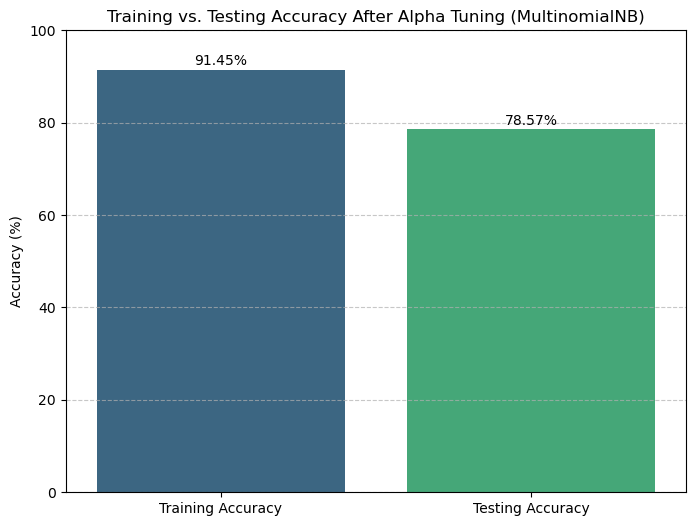

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Assuming train_acc_tuned and test_acc_tuned are available from previous steps
# If not, recalculate them:
# train_acc_tuned = model_for_prediction.score(X_train, y_train)
# test_acc_tuned = model_for_prediction.score(X_test, y_test)

accuracies = {
    'Training Accuracy': train_acc * 100, # Convert to percentage
    'Testing Accuracy': test_acc * 100    # Convert to percentage
}

model_names = list(accuracies.keys())
scores = list(accuracies.values())

plt.figure(figsize=(8, 6))
sns.barplot(x=model_names, y=scores, hue=model_names, palette='viridis', legend=False)
plt.title('Training vs. Testing Accuracy After Alpha Tuning (MultinomialNB)')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100) # Set the y-axis limit to 100 for better visualization of percentages

# Add the percentage values on top of the bars
for index, value in enumerate(scores):
    plt.text(index, value + 1, f'{value:.2f}%', ha='center')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Step 13: Visualizing MultinomialNB Performance Before and After Alpha Tuning

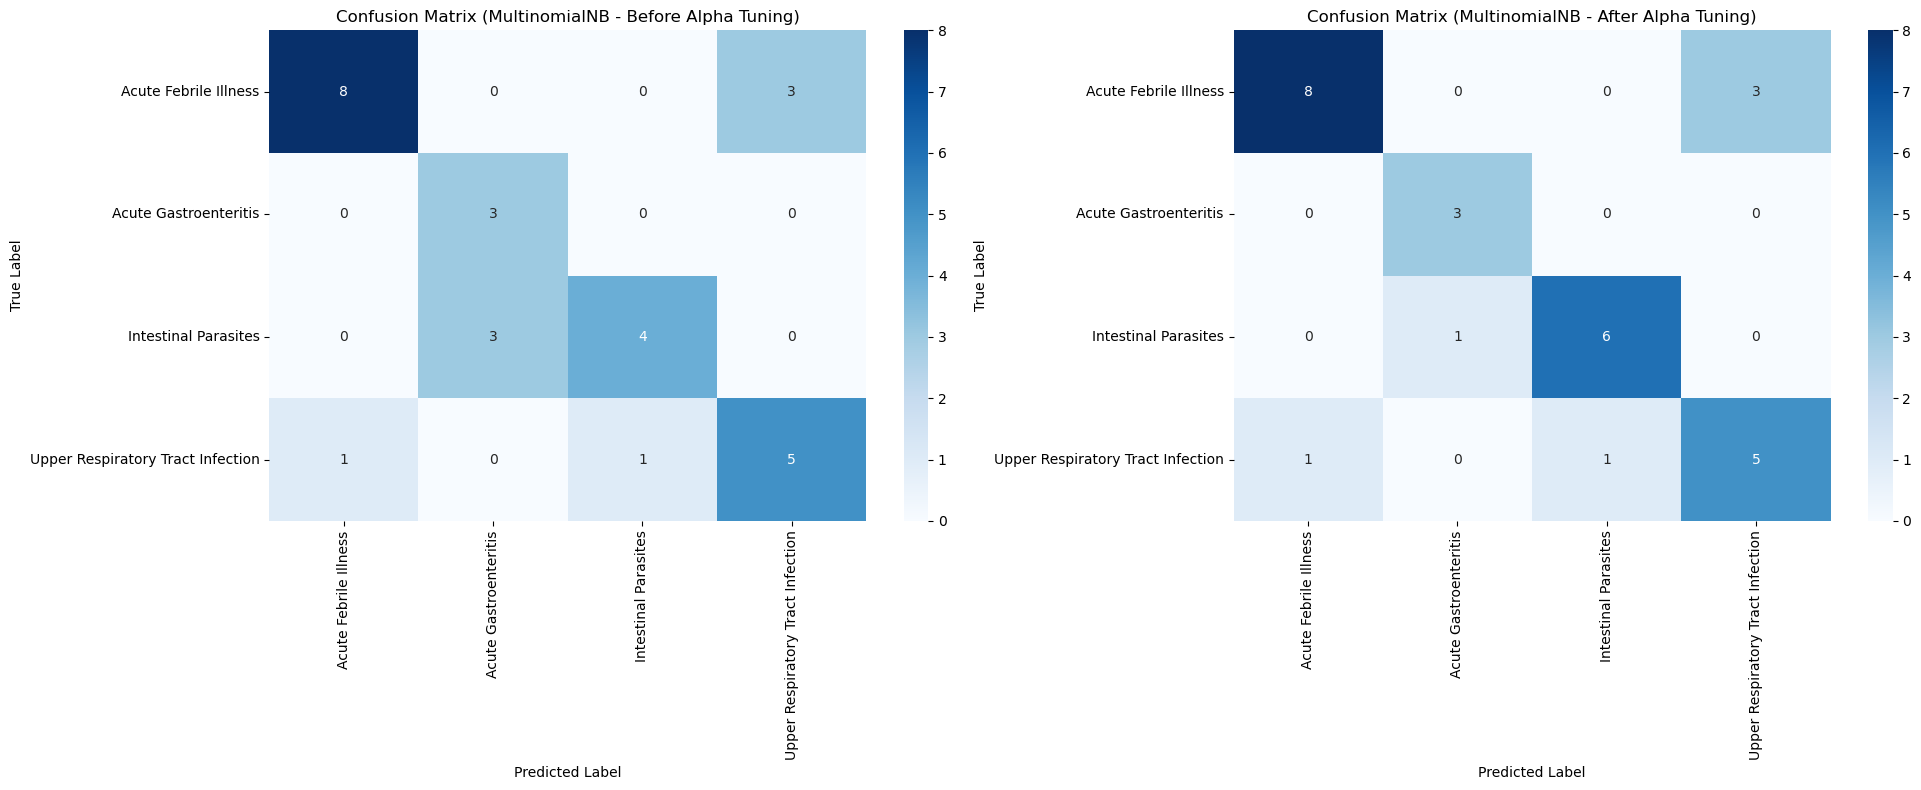

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Check if cm_nb_before_tune and cm_nb_after_tune exist before plotting
if 'cm_nb_before_tune' in locals() and 'cm_nb_after_tune' in locals():
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))

    # Plot Confusion Matrix Before Tuning
    sns.heatmap(cm_nb_before_tune, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
    axes[0].set_title('Confusion Matrix (MultinomialNB - Before Alpha Tuning)')
    axes[0].set_xlabel('Predicted Label')
    axes[0].set_ylabel('True Label')

    # Plot Confusion Matrix After Tuning
    sns.heatmap(cm_nb_after_tune, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[1])
    axes[1].set_title('Confusion Matrix (MultinomialNB - After Alpha Tuning)')
    axes[1].set_xlabel('Predicted Label')
    axes[1].set_ylabel('True Label')

    plt.tight_layout()
    plt.show()
else:
    print("Confusion matrices for MultinomialNB before and after tuning are not available. Please run the tuning step first.")


## Learning Curve After Parameter Tuning

## Step 14: Model Deployment

In [ ]:
import re

#============================================================
# custome and helping functions
#==========================helper funtions================
def helper(dis):
    # Ensure to get the single string value from the Series
    desc = description[description['Disease'] == dis]['Description'].iloc[0]

    # Precaution column is a single string, split it into a list of individual precautions
    pre = precautions[precautions['Disease'] == dis]['Precaution'].iloc[0].split(', ')

    # Medication column is named 'medication' (lowercase)
    med = medications[medications['Disease'] == dis]['medication'].iloc[0].split(', ')

    # Diets column is named 'Diets' (capital D)
    die = diets[diets['Disease'] == dis]['Diets'].iloc[0].split(', ')

    # Handling 'Dosage'
    dosage_info_list = []
    processed_medications = set() # To keep track of medications already processed for dosage

    for medication_from_meds_list in med:
        # Create a regex pattern to match the whole word, case-insensitive for exact matches
        # This ensures that 'Chloroquine' doesn't match 'Hydroxychloroquine' if only 'Chloroquine' is in med
        pattern = r'\b' + re.escape(medication_from_meds_list) + r'\b'

        # Find all matching treatments in the Dosage DataFrame
        matching_treatments_df = Dosage[Dosage['Treatment'].str.contains(pattern, case=False, na=False, regex=True)]

        found_dosage = False
        if not matching_treatments_df.empty:
            for _, row in matching_treatments_df.iterrows():
                treatment_name = row['Treatment']
                dosage_value = row['Dosage']
                if treatment_name not in processed_medications:
                    dosage_info_list.append(f"{treatment_name}: {dosage_value}")
                    processed_medications.add(treatment_name)
                    found_dosage = True

        # If no specific dosage was found for this medication from the 'med' list
        if not found_dosage and medication_from_meds_list not in processed_medications:
            dosage_info_list.append(f"{medication_from_meds_list}: No specific dosage information available.")
            processed_medications.add(medication_from_meds_list)

    # Fallback if no medications were suggested or no dosage info was generated at all
    if not dosage_info_list and not med:
        dosage_info_list = ["No specific dosage information available for the recommended medications."]

    return desc, pre, med, die, dosage_info_list
symptoms_dict = {symptom: index for index, symptom in enumerate(X.columns)}
diseases_list = le.classes_.tolist()

# Model Prediction function
def get_predicted_value(age, patient_symptoms):
    input_vector = np.zeros(len(symptoms_dict))
    # Set age in the input vector
    if 'Age' in symptoms_dict:
        input_vector[symptoms_dict['Age']] = age

    for item in patient_symptoms:
        if item in symptoms_dict:
            input_vector[symptoms_dict[item]] = 1
        else:
    
            print(f"Warning: Symptom '{item}' not recognized and will be ignored for prediction.")
    predicted_label_index = model_for_prediction.predict([input_vector])[0] # Changed svc.predict to model_for_prediction.predict
    return diseases_list[predicted_label_index]
age_input = 25
symptoms = input("Enter your symptoms.......") # User still inputs symptoms
user_symptoms = [s.strip() for s in symptoms.split(',')]
# Remove any extra characters, if any
user_symptoms = [symptom.strip("[]' ") for symptom in user_symptoms]
predicted_disease = get_predicted_value(age_input, user_symptoms) # Pass age_input

desc, pre, med, die, dosage_info = helper(predicted_disease)

print("=================predicted disease===========")
print(predicted_disease)
print("=================description=================")
print(desc)

print("=================medications=================")
if med:
    for m_i in med:
        print(f"- {m_i}")
else:
    print("  None")

print("=================Dosage=====================")
if dosage_info:
    for d_i in dosage_info:
        print(f"- {d_i}")
else:
    print("  No specific dosage information available.")

print("=================diets======================")
if die:
    for d_i in die:
        print(f"- {d_i}")
else:
    print("  None")

print("=================precautions=================")
# Iterate directly over the list of precautions, not characters of the first item
if pre:
    for p_i in pre:
        print(f"- {p_i}")
else:
    print("  None")

Enter your symptoms....... chills


=================predicted disease===========
Acute Febrile Illness
=================description=================
AFI is a clinical syndrome characterized by a sudden onset of fever due to underlying infectious or inflammatory causes of viral, bacterial, or parasitic origin.
=================medications=================
- Chloroquine
- Primaquine
- Paracetamol
- Coartem
- Diclofenac
- Ciprofloxacin
- Cimetidine
- Glucose IV
- Cephalexin
- Chlorpheniramine
- Artesunate
- Artemether
- Antipyretics
=================Dosage=====================
- Chloroquine: Chloroquine standard regimen (200 mg base orally daily)
- Primaquine: Primaquine 15 mg daily x 14 days
- Paracetamol: Paracetamol 500 mg orally as needed for fever
- Coartem: Coartem 4 tablets twice daily for 3 days
- Diclofenac: 50 mg orally as needed for pain
- Ciprofloxacin: 500 mg orally twice daily for 5–10 days
- Cimetidine: Cimetidine IV injection
- Glucose IV: 40% Glucose IV solution
- Cephalexin: Cephalexin 500 mg twice daily 

C:\Users\lenevo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MultinomialNB was fitted with feature names
  warnings.warn(


## Step 15:Usual interface by Gradio deployment

In [ ]:
import numpy as np
import gradio as gr
import re # Import the re module for regular expressions
import os

# Define svc with the best model identified from the comparison for Gradio interface
# This addresses the UserWarning about `svc` not having valid feature names.
svc = model_for_prediction

# -------------------------
# Helper function
# -------------------------
def helper(dis):
    # Ensure to get the single string value from the Series
    desc = description[description['Disease'] == dis]['Description'].iloc[0]

    # Precaution column is a single string, split it into a list of individual precautions
    pre = precautions[precautions['Disease'] == dis]['Precaution'].iloc[0].split(', ')

    # Medication column is named 'medication' (lowercase)
    med = medications[medications['Disease'] == dis]['medication'].iloc[0].split(', ')

    # Diets column is named 'Diets' (capital D)
    die = diets[diets['Disease'] == dis]['Diets'].iloc[0].split(', ')

    # Handling 'Dosage'
    dosage_info_list = []
    processed_medications = set() # To keep track of medications already processed for dosage

    for medication_from_meds_list in med:
        # Create a regex pattern to match the whole word, case-insensitive for exact matches
        # This ensures that 'Chloroquine' doesn't match 'Hydroxychloroquine' if only 'Chloroquine' is in med
        pattern = r'\b' + re.escape(medication_from_meds_list) + r'\b'

        # Find all matching treatments in the Dosage DataFrame
        matching_treatments_df = Dosage[Dosage['Treatment'].str.contains(pattern, case=False, na=False, regex=True)]

        found_dosage = False
        if not matching_treatments_df.empty:
            for _, row in matching_treatments_df.iterrows():
                treatment_name = row['Treatment']
                dosage_value = row['Dosage']
                if treatment_name not in processed_medications:
                    dosage_info_list.append(f"{treatment_name}: {dosage_value}")
                    processed_medications.add(treatment_name)
                    found_dosage = True

        # If no specific dosage was found for this medication from the 'med' list
        if not found_dosage and medication_from_meds_list not in processed_medications:
            dosage_info_list.append(f"{medication_from_meds_list}: No specific dosage information available.")
            processed_medications.add(medication_from_meds_list)

    # Fallback if no medications were suggested or no dosage info was generated at all
    if not dosage_info_list and not med:
        dosage_info_list = ["No specific dosage information available for the recommended medications."]

    return desc, pre, med, die, dosage_info_list


# -------------------------
# Model prediction function
# -------------------------
def get_predicted_value(age, patient_symptoms):
    input_vector = np.zeros(len(symptoms_dict))

    # Set age in the input vector
    if 'Age' in symptoms_dict:
        input_vector[symptoms_dict['Age']] = age

    # Set symptoms in the input vector
    for item in patient_symptoms:
        if item in symptoms_dict:
            input_vector[symptoms_dict[item]] = 1
        else:
            print(f"Warning: Symptom '{item}' not recognized and will be ignored for prediction.")

    # svc.predict returns an array, take the first element for the label index
    predicted_label_index = svc.predict([input_vector])[0]
    return diseases_list[predicted_label_index]


# -------------------------
# Interface function
# -------------------------
def predict_disease_interface(age, selected_symptoms):
    # Handle empty input safely
    if age is None:
        return "Please enter your age."
    if not (20 <= age <= 27):
        return "Age must be between 20 and 27 (inclusive)."
    if not selected_symptoms:
        return "Please select at least one symptom."


    predicted_disease = get_predicted_value(age, selected_symptoms)
    desc, pre, med, die, dosage_info = helper(predicted_disease)

    output_text = f"predicted disease: {predicted_disease}\n\n"
    output_text += f"Description of Disease: {desc}\n\n"

    output_text += "Medication:\n"
    if med:
        for m_i in med:
            output_text += f"- {m_i}\n"
    else:
        output_text += "  None\n"
    output_text += "\n"

    output_text += "Dosage:\n"
    if dosage_info:
        for d_i in dosage_info:
            output_text += f"- {d_i}\n"
    else:
        output_text += "  No specific dosage information available.\n"
    output_text += "\n"

    output_text += "Diet:\n"
    if die:
        for d_i in die:
            output_text += f"- {d_i}\n"
    else:
        output_text += "  None\n"
    output_text += "\n"

    output_text += "Precaution:\n"
    if pre:
        for p_i in pre:
            output_text += f"- {p_i}\n"
    else:
        output_text += "  None\n"
    output_text += "\n"

    return output_text


# -------------------------
# Gradio Interface
# -------------------------
symptom_list = sorted([s for s in symptoms_dict.keys() if s != 'Age']) # Exclude 'Age' from symptom list

interface = gr.Interface(
    fn=predict_disease_interface,
    inputs=[
        gr.Number(label="Age", minimum=1, maximum=120, step=1, value=20),
        gr.Dropdown(
            choices=symptom_list,
            label="Select your symptoms",
            multiselect=True
        )
    ],
    outputs="text",
    title="Disease Prediction and Medical Recommendation System",
    description="Enter your age and select symptoms to get a disease prediction and recommendations."
)

# To run on Cloud Run, Gradio needs to listen on 0.0.0.0 and a specific port (default 7860)
# For local Colab execution, it's often better to let Gradio pick an available port automatically
# by removing the server_port argument.
if __name__ == "__main__":
    interface.launch(server_name="0.0.0.0", share=False)

* Running on local URL:  http://0.0.0.0:7860
* To create a public link, set `share=True` in `launch()`.


C:\Users\lenevo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MultinomialNB was fitted with feature names
  warnings.warn(
C:\Users\lenevo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MultinomialNB was fitted with feature names
  warnings.warn(
C:\Users\lenevo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MultinomialNB was fitted with feature names
  warnings.warn(
